In [12]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import OpenImageIO as oiio
import re
from tqdm import tqdm

def imread(input_path):
    input_path = str(input_path)
    inp = oiio.ImageInput.open(input_path)
    assert inp, f"Cannot open {input_path}"

    spec = inp.spec()
    xres, yres, channels = spec.width, spec.height, spec.nchannels

    # Read
    image = inp.read_image(0, 0, 0, channels)
    inp.close()

    return image, spec


def imwrite(image: np.ndarray, output_path, gamma_correction=True):
    output_path = str(output_path)
    xres, yres, channels = image.shape[1], image.shape[0], image.shape[2]
    if output_path.endswith('.png') and gamma_correction:
        image = image ** (1 / 2.2)  # gamma correction

    out = oiio.ImageOutput.create(output_path)
    assert out
    print(f"Writing an image to {output_path}")

    spec = oiio.ImageSpec(xres, yres, channels, str(image.dtype))
    out.open(output_path, spec)
    out.write_image(np.ascontiguousarray(image))
    out.close()


def select_channels(image, spec, channel_names):
    for name in channel_names:
        if name not in spec.channelnames:
            raise ValueError(f"Channel {name} not found in the image")
    return image[:, :, [spec.channelnames.index(name) for name in channel_names]]

In [14]:
error_percentile = 0.90

def robust_mean_error(error_map):
    error_values = np.sort(error_map.flatten())
    return np.mean(error_values[:int(error_percentile * len(error_values))])

def MRAE(im, ref):
    # return np.mean(np.minimum(np.abs(im - ref) / (ref + 1e-2), 1e2))
    error_map = (np.abs(im - ref) / (ref + 1e-2)).mean(axis=2)
    return robust_mean_error(error_map)

def MRSE(im, ref):
    # return np.mean(np.minimum((im - ref) ** 2 / (ref ** 2 + 1e-2), 1e3))
    error_map = ((im - ref) ** 2 / (ref ** 2 + 1e-2)).mean(axis=2)
    return robust_mean_error(error_map)

pattern1 = re.compile(r"update\(\) took (\d+\.\d+|\d\.\d+e-\d+) seconds")
pattern2 = re.compile(r"total valid regions: (\d+)")
pattern3 = re.compile(r"updateField\(\) took (\d+\.\d+|\d\.\d+e-\d+) seconds")

class Record:
    def __init__(self, folder: Path, scene_name: str, spp: int, descr: str):
        self.folder = folder
        self.scene_name = scene_name
        self.training_log = folder / f"{scene_name}-t{spp}-generate_cache_{descr}.log"
        self.descr = descr
        self.spp = spp
        self.train_iterations = []
        self.train_mraes = []
        self.train_mrses = []
        self.eval_mrae = 0
        self.eval_mrse = 0
        self.num_regions = []
        self.subdivision_times = []
        self.training_times = []
        self.read_log()

    def compute_eval_error(self, reference: np.ndarray):
        path = self.folder / f"{self.scene_name}-t{self.spp}-surface_guiding_cache_quality_{self.descr}.exr"
        assert path.exists(), f"Eval image not found: {path}"
        im, spec = imread(path)
        im = select_channels(im, spec, ['R', 'G', 'B'])
        self.eval_mrae = MRAE(im, reference)
        self.eval_mrse = MRSE(im, reference)

    def compute_errors(self, reference: np.ndarray):
        self.train_iterations.clear()
        self.train_mraes.clear()
        self.train_mrses.clear()
        # search in folder for all images of this descr
        for i in range(1, 1 + self.spp):
            if i == self.spp:
                path = self.folder / f"{self.scene_name}-t{self.spp}-generate_cache_{self.descr}.exr"
            else:
                path = self.folder / f"{self.scene_name}-t{self.spp}-generate_cache_{self.descr}-{i}spp.exr"
            if path.exists():
                im, spec = imread(path)
                im = select_channels(im, spec, ['R', 'G', 'B'])
                self.train_iterations.append(i)
                self.train_mraes.append(MRAE(im, reference))
                self.train_mrses.append(MRSE(im, reference))
        # eval
        path = self.folder / f"{self.scene_name}-t{self.spp}-surface_guiding_cache_quality_{self.descr}.exr"
        assert path.exists(), f"Eval image not found: {path}"
        im, spec = imread(path)
        im = select_channels(im, spec, ['R', 'G', 'B'])
        self.eval_mrae = MRAE(im, reference)
        self.eval_mrse = MRSE(im, reference)
    
    def read_log(self):
        with open(self.training_log, 'r') as f:
            text = f.read()
        for match in pattern1.finditer(text):
            self.subdivision_times.append(float(match.group(1)))
        for match in pattern2.finditer(text):
            self.num_regions.append(int(match.group(1)))
        for match in pattern3.finditer(text):
            self.training_times.append(float(match.group(1)))
        assert len(self.training_times) == len(self.subdivision_times) + 1, f"{self.training_log}: {len(self.training_times)} {len(self.subdivision_times)}"


class Method:
    def __init__(self, name, folder, descr, color=None, linestyle=None):
        self.name = name
        self.folder = folder
        self.descr = descr
        self.color = color
        self.linestyle = linestyle


result_dir = Path('/local/home/zhengfe/Thesis/PBRT-v4/results')
scene_configs = [
    ["torus", "", "Cube"],
    ["torus", "-glass", "Torus"],
    ["torus", "-multi-complex", "Multi Cubes"],
    ["cbox-classic", "", "Cornell Box"],
    ["projection-box", "", "Projection Box"],
    ["water-caustic", "", "Water Caustic"],
    ["classroom", "-day", "Classroom Day"],
    ["classroom", "-lightson", "Classroom Lights-on"],
    ["CoronaBenchmark2", "", "Living Room"],
    ["sanmiguel", "-courtyard-second", "San Miguel Courtyard"],
    ["sanmiguel", "-in-tree", "San Miguel Trees"],
    ["pool", "", "Pool"],
    ["villa", "-daylight", "Villa"],
    ["kitchen", "", "Kitchen"],
    ["bathroom2", "", "Bathroom"],
]

colors_baseline = ['y', 'darkgreen', 'limegreen']
colors_ce = ['fuchsia', 'red', 'brown']
colors_mis = ['midnightblue', 'royalblue', 'deepskyblue']

colors_ppg_baseline = ['tab:blue', 'tab:green']
colors_scanning = ['tab:orange', 'tab:red', 'tab:purple', 'tab:brown']

# 16 SPP
# methods = [  # Baseline
#     Method(f"Baseline+{m}k", result_dir / 'adaptive_div', f"baseline_l{m}k", color=colors[i], linestyle="--") 
#     for i, m in enumerate([32, 8, 2])
# ]
# methods += [  # CE
#     Method(f"CE-{t}", result_dir / 'adaptive_div', f"entropy_baseline_t{t}_de0.25_l128k_d32", color=colors[i], linestyle='-') 
#     for i, t in enumerate([0, 0.01, 0.05, 0.1])
# ]
# methods += [  # MIS
#     Method(f"MIS-{t}", result_dir / 'adaptive_mis', f"mis_baseline_t{t}_l128k_d32", color=colors[i], linestyle=':') 
#     for i, t in enumerate([0.5, 0.6, 0.9])
# ]

# 64 SPP
# methods = [  # Baseline
#     Method(f"Baseline-{m}k", result_dir / 'full', f"baseline_l{m}k", color=colors_baseline[i], linestyle="--") 
#     for i, m in enumerate([32, 8, 2])
# ]
# methods += [  # CE
#     Method(f"CE-{t}", result_dir / 'full', f"entropy_baseline_t{t}_de0.25_l512k_d12", color=colors_ce[i], linestyle='-') 
#     for i, t in enumerate([0, 0.02, 0.1])
# ]

# # VS
# methods = [
#     Method("PPG", result_dir / 'vs', 'ppg', color=colors_ppg_baseline[0], linestyle='--'),
#     Method("Baseline", result_dir / 'vs', 'baseline', color=colors_ppg_baseline[1], linestyle='--'),

#     Method("VS", result_dir / 'vs', 'vs', color=colors_scanning[0], linestyle='-'),
#     Method("COVS", result_dir / 'vs', 'covs', color=colors_scanning[1], linestyle='-'),
#     Method("IGS", result_dir / 'vs', 'igs', color=colors_scanning[2], linestyle='-'),
#     Method("FS", result_dir / 'vs', 'fs', color=colors_scanning[3], linestyle='-'),
# ]

# Full
baselines = [
    Method(f"Baseline-{m}k", result_dir / 'full', f"baseline_l{m}k", color=colors_ppg_baseline[1], linestyle="--")
    for m in [2, 8, 32]
]
ces = [
    Method(f"CE-{t}", result_dir / 'full', f"entropy_baseline_t{t}_de0.25_l512k_d12", color=colors_ppg_baseline[0], linestyle=":")
    for t in [0, 0.02, 0.1]
]
ce_vss = [
    Method(f"CE-VS-{t}", result_dir / 'full', f"entropy_vs_t{t}_de0.25_l512k_d12", color=colors_scanning[0], linestyle="-")
    for t in [0, 0.02, 0.1]
]
# ce_covss = [
#     Method(f"CE-COVS-{t}", result_dir / 'full', f"entropy_covs_t{t}_de0.25_l512k_d12", color=colors_scanning[1], linestyle="-")
#     for t in [0, 0.02, 0.1]
# ]
ce_igss = [
    Method(f"CE-IGS-{t}", result_dir / 'full', f"entropy_igs_t{t}_de0.25_l512k_d12", color=colors_scanning[2], linestyle="-")
    for t in [0, 0.02, 0.1]
]
ce_fss = [
    Method(f"CE-FS-{t}", result_dir / 'full', f"entropy_fs_t{t}_de0.25_l512k_d12", color=colors_scanning[3], linestyle="-")
    for t in [0, 0.02, 0.1]
]
methods = baselines + ces + ce_vss + ce_igss + ce_fss

In [9]:
# method = baselines[2]
method = ces[1]
scene = "torus"
scene_name = "torus-multi-complex"
spp = 64
record = Record(method.folder / scene, scene_name, spp, method.descr)
record.num_regions[-1]

2614

In [10]:
method = Method("Baseline-18k", result_dir / 'planar', "baseline_l18k", color=colors_ppg_baseline[1], linestyle="--")
# method = Method("CE-0.01", result_dir / 'planar', "entropy_baseline_t0.01_de0.25_l128k_d12", color=colors_ppg_baseline[1], linestyle="--")
scene = "plane"
scene_name = "plane-shadow-complex"
spp = 16
record = Record(method.folder / scene, scene_name, spp, method.descr)
record.num_regions[-1]

393

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

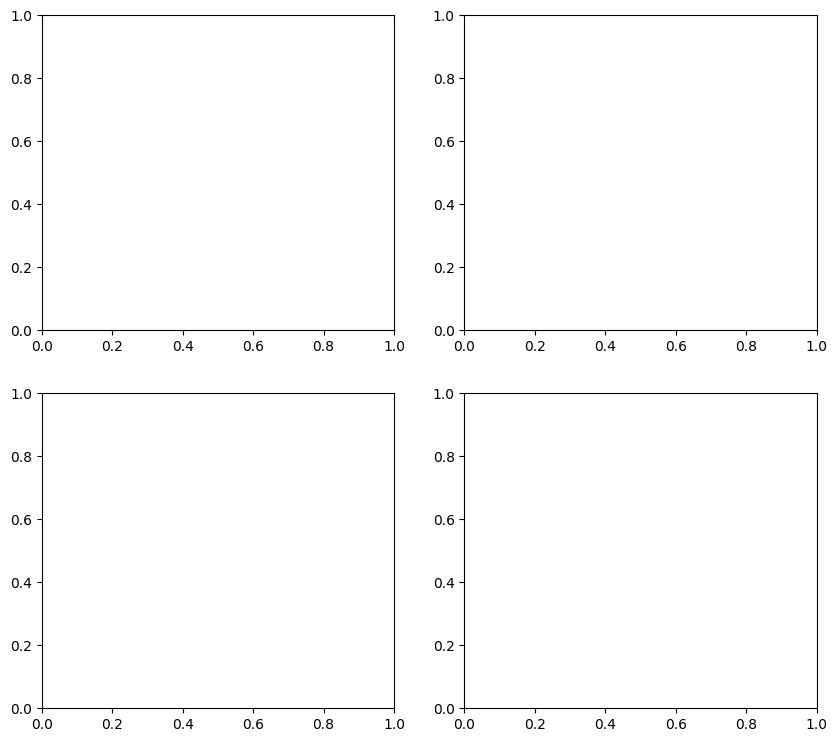

In [11]:
# Plot the number of regions, subdivision time, and errors

spp = 64
dspp = 4
experiment = 'full'

for scene, variant, title in tqdm(scene_configs[-1:]):
    scene_name = f"{scene}{variant}"
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    iters = np.arange(1, spp + 1)

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    eval_mraes = {}
    eval_mrses = {}

    for method in methods:
        record = Record(method.folder / scene, scene_name, spp, method.descr)
        record.compute_errors(reference)
        num_regions = record.num_regions
        if len(num_regions) == spp:
            axes[0, 0].plot(iters, num_regions, label=method.name, color=method.color, linestyle=method.linestyle)
        subdivision_times = record.subdivision_times
        if len(subdivision_times) == spp:
            axes[0, 1].plot(iters, subdivision_times, label=method.name, color=method.color, linestyle=method.linestyle)
        
        x = record.train_iterations
        mraes = record.train_mraes
        axes[1, 0].plot(x, mraes, label=method.name, color=method.color, linestyle=method.linestyle)
        axes[1, 0].plot([spp, spp + dspp], [mraes[-1], record.eval_mrae], color=method.color, linestyle=method.linestyle, alpha=0.5)
        mrses = record.train_mrses
        axes[1, 1].plot(x, mrses, label=method.name, color=method.color, linestyle=method.linestyle)
        axes[1, 1].plot([spp, spp + dspp], [mrses[-1], record.eval_mrse], color=method.color, linestyle=method.linestyle, alpha=0.5)

        eval_mraes[method.name] = record.eval_mrae
        eval_mrses[method.name] = record.eval_mrse

    # Find best methods
    best_mrae_method = min(eval_mraes, key=eval_mraes.get)
    best_mrse_method = min(eval_mrses, key=eval_mrses.get)

    axes[0, 0].set_title("Number of Regions")
    axes[0, 0].legend()
    axes[0, 1].set_title("Subdivision Time")
    axes[0, 1].legend()

    xticks = list(range(dspp, spp + 1, spp // 8))
    xticks.append(spp + dspp)
    xticks_labels = [str(x) for x in xticks]
    xticks_labels[-1] = "eval"

    axes[1, 0].set_xticks(xticks, xticks_labels)
    axes[1, 0].set_title("MRAE")
    legend = axes[1, 0].legend()
    for text in legend.get_texts():
        if text.get_text() == best_mrae_method:
            text.set_fontweight('bold')

    axes[1, 1].set_xticks(xticks, xticks_labels)
    axes[1, 1].set_title("MRSE")
    legend = axes[1, 1].legend()
    for text in legend.get_texts():
        if text.get_text() == best_mrse_method:
            text.set_fontweight('bold')

    fig.suptitle(title)
    plt.tight_layout()
    outpath = Path(f"output/{experiment}/{title}-stats.pdf")
    outpath.parent.mkdir(parents=True, exist_ok=True)
    # plt.savefig(outpath)
    # print(f"Saved to {outpath}")
    plt.show()
    plt.close()

In [ ]:
# Plot the number of regions and MARE curve

spp = 64
dspp = 4
experiment = 'full-baseline-vs-ce'

for scene, variant, title in tqdm(scene_configs):
    scene_name = f"{scene}{variant}"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    iters = np.arange(1, spp + 1)

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    eval_mraes = {}

    for method in methods:
        record = Record(method.folder / scene, scene_name, spp, method.descr)
        record.compute_errors(reference)
        num_regions = record.num_regions
        if len(num_regions) == spp:
            axes[0].plot(iters, num_regions, label=method.name, color=method.color, linestyle=method.linestyle)
        
        x = record.train_iterations
        mraes = record.train_mraes
        axes[1].plot(x, mraes, label=method.name, color=method.color, linestyle=method.linestyle)
        axes[1].plot([spp, spp + dspp], [mraes[-1], record.eval_mrae], color=method.color, linestyle=method.linestyle, alpha=0.5)
        eval_mraes[method.name] = record.eval_mrae

    # Find best methods
    best_mrae_method = min(eval_mraes, key=eval_mraes.get)

    yticks_labels = [f"{y // 1000}k" for y in axes[0].get_yticks()]
    axes[0].set_yticklabels(yticks_labels)
    axes[0].set_title("Number of Regions")
    axes[0].set_xlabel("iteration")
    # axes[0].legend()

    xticks = list(range(dspp, spp + 1, spp // 8))
    xticks.append(spp + dspp)
    xticks_labels = [str(x) for x in xticks]
    xticks_labels[-1] = "eval"

    axes[1].set_yscale('log')
    axes[1].set_xticks(xticks, xticks_labels)
    axes[1].set_title("MRAE")
    axes[1].set_xlabel("iteration")
    legend = axes[1].legend()
    for text in legend.get_texts():
        if text.get_text() == best_mrae_method:
            text.set_fontweight('bold')

    fig.suptitle(title)
    plt.tight_layout()
    outpath = Path(f"output/{experiment}/{title}.pdf")
    outpath.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(outpath)
    print(f"Saved to {outpath}")
    plt.close()

  0%|          | 0/14 [00:00<?, ?it/s]

/tmp/ipykernel_3022423/2979596350.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels(yticks_labels)
  7%|▋         | 1/14 [00:04<00:54,  4.20s/it]

Saved to output/full-baseline-vs-ce/Cube.pdf


/tmp/ipykernel_3022423/2979596350.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels(yticks_labels)
 14%|█▍        | 2/14 [00:08<00:50,  4.21s/it]

Saved to output/full-baseline-vs-ce/Torus.pdf


...

Saved to output/full-baseline-vs-ce/Villa.pdf


/tmp/ipykernel_3022423/2979596350.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels(yticks_labels)
 93%|█████████▎| 13/14 [01:44<00:09,  9.52s/it]

Saved to output/full-baseline-vs-ce/Kitchen.pdf


/tmp/ipykernel_3022423/2979596350.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_yticklabels(yticks_labels)
100%|██████████| 14/14 [01:50<00:00,  7.90s/it]

Saved to output/full-baseline-vs-ce/Bathroom.pdf


In [ ]:
# Plot the MARE curve

spp = 8
dspp = 1
experiment = 'vs'

for scene, variant, title in tqdm(scene_configs):
    scene_name = f"{scene}{variant}"
    fig, ax = plt.subplots(figsize=(6, 4.5))
    iters = np.arange(1, spp + 1)

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    eval_mraes = {}
    upper_mrae = 1e9

    for method in methods:
        record = Record(method.folder / scene, scene_name, spp, method.descr)
        record.compute_errors(reference)
        x = record.train_iterations
        mraes = record.train_mraes
        upper_mrae = min(upper_mrae, max(mraes[3:]))
        ax.plot(x, mraes, label=method.name, color=method.color, linestyle=method.linestyle)
        # ax.plot([spp, spp + dspp], [mraes[-1], record.eval_mrae], color=method.color, linestyle=method.linestyle, alpha=0.5)
        # eval_mraes[method.name] = record.eval_mrae
        eval_mraes[method.name] = mraes[-1]

    # Find best methods
    best_mrae_method = min(eval_mraes, key=eval_mraes.get)

    # xticks = list(range(dspp, spp + 1, spp // 8))
    # xticks.append(spp + dspp)
    # xticks_labels = [str(x) for x in xticks]
    # xticks_labels[-1] = "eval"

    ax.set_ylim(ax.get_ylim()[0], min(upper_mrae*1.2, ax.get_ylim()[1]))
    # ax.set_yscale('log')
    # ax.set_xticks(xticks, xticks_labels)
    ax.set_ylabel("MRAE")
    ax.set_xlabel("iteration")
    ax.set_title(title)
    legend = ax.legend()
    for text in legend.get_texts():
        if text.get_text() == best_mrae_method:
            text.set_fontweight('bold')

    plt.tight_layout()
    outpath = Path(f"output/{experiment}/{title}.pdf")
    outpath.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(outpath)
    print(f"Saved to {outpath}")
    plt.close()

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:03<00:00,  3.05s/it]

Saved to output/vs/Multi Cubes.pdf


In [ ]:
# Plot the MARE curve

spp = 64
dspp = 4
experiment = 'full'

for scene, variant, title in tqdm(scene_configs):
    scene_name = f"{scene}{variant}"
    fig, ax = plt.subplots(figsize=(6, 4.5))
    iters = np.arange(1, spp + 1)

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    eval_mraes = {}
    for group in [baselines, ces, ce_vss, ce_igss, ce_fss]:
        # Find the most performant method for each type of models
        eval_mrae_list = []
        for method in group:
            record = Record(method.folder / scene, scene_name, spp, method.descr)
            record.compute_eval_error(reference)
            eval_mrae_list.append(record.eval_mrae)
        
        best_id = np.argmin(eval_mrae_list)
        method = group[best_id]
        record = Record(method.folder / scene, scene_name, spp, method.descr)
        record.compute_errors(reference)
        x = record.train_iterations
        mraes = record.train_mraes
        eval_mraes[method.name] = record.eval_mrae
        assert record.eval_mrae == eval_mrae_list[best_id]
        ax.plot(x, mraes, label=method.name, color=method.color, linestyle=method.linestyle)
        ax.plot([spp, spp + dspp], [mraes[-1], eval_mrae_list[best_id]], color=method.color, linestyle=method.linestyle, alpha=0.5)
    
    # Find the best method
    best_mrae_method = min(eval_mraes, key=eval_mraes.get)

    xticks = list(range(dspp, spp + 1, spp // 8))
    xticks.append(spp + dspp)
    xticks_labels = [str(x) for x in xticks]
    xticks_labels[-1] = "eval"

    ax.set_yscale('log')
    ax.set_xticks(xticks, xticks_labels)
    ax.set_ylabel("MRAE")
    ax.set_xlabel("iteration")
    ax.set_title(title)
    legend = ax.legend()
    for text in legend.get_texts():
        if text.get_text() == best_mrae_method:
            text.set_fontweight('bold')

    plt.tight_layout()
    outpath = Path(f"output/{experiment}/{title}.pdf")
    outpath.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(outpath)
    print(f"Saved to {outpath}")
    plt.close()

  7%|▋         | 1/15 [00:04<00:58,  4.15s/it]

Saved to output/full/Cube.pdf


 13%|█▎        | 2/15 [00:08<00:54,  4.19s/it]

Saved to output/full/Torus.pdf


 20%|██        | 3/15 [00:12<00:50,  4.18s/it]

...

Saved to output/full/Villa.pdf


 93%|█████████▎| 14/15 [01:54<00:09,  9.17s/it]

Saved to output/full/Kitchen.pdf


100%|██████████| 15/15 [01:59<00:00,  7.96s/it]

Saved to output/full/Bathroom.pdf


In [20]:
# Bar plot showing the performance gain of each method over the baseline
error_percentile = 0.95

spp = 64
experiment = 'full'

performances_per_scene = []  # id -> [(method_1, gain_method_1), (method_2, gain_method_2), ...]

for scene, variant, title in tqdm(scene_configs):
    scene_name = f"{scene}{variant}"

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    performances = []
    baseline_error = None
    for i, group in enumerate([baselines, ces, ce_vss, ce_igss, ce_fss]):
        # Find the most performant method for each type of models
        eval_mrae_list = []
        for method in group:
            record = Record(method.folder / scene, scene_name, spp, method.descr)
            record.compute_eval_error(reference)
            eval_mrae_list.append(record.eval_mrae)
        
        best_id = np.argmin(eval_mrae_list)
        error = eval_mrae_list[best_id]
        method = group[best_id]

        if i == 0:
            baseline_error = error
            performances.append((method, 0))
        else:
            performances.append((method, (baseline_error - error) / baseline_error))

    performances_per_scene.append(performances)
    
# Plot the bars for all the scenes in a single figure
fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.15
bar_positions = np.arange(len(scene_configs))

for i, group in enumerate([ces, ce_vss, ce_igss, ce_fss]):
    name = '-'.join(group[0].name.split('-')[:-1])
    gains = [performances[1+i][1] for performances in performances_per_scene]
    ax.bar(bar_positions + i * bar_width, gains, bar_width, label=name, color=group[0].color, zorder=3)

ax.set_xticks(bar_positions + 2 * bar_width)
ax.set_xticklabels([title for _, _, title in scene_configs], rotation=45)
ax.axhline(0, color='gray', linestyle='-')
# Y labels percentage
ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])
ax.set_ylabel("Gain")
ax.set_title(f"Performance Gain over Baseline (MRAE)")
ax.legend()
ax.grid(True, axis='y', linestyle='--', zorder=0)
plt.tight_layout()
outpath = Path(f"output/{experiment}/performance_gain_mrae_{int(error_percentile*100)}%.pdf")
outpath.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(outpath)
print(f"Saved to {outpath}")
plt.close()

# performances_per_scene_a = performances_per_scene[:8]
# performances_per_scene_b = performances_per_scene[8:]
# scene_configs_a = scene_configs[:8]
# scene_configs_b = scene_configs[8:]

# for x, performances_per_scene_x, scene_configs_x in [('a', performances_per_scene_a, scene_configs_a), ('b', performances_per_scene_b, scene_configs_b)]:
#     # Plot the bars for all the scenes in a single figure
#     fig, ax = plt.subplots(figsize=(12, 5))
#     bar_width = 0.15
#     bar_positions = np.arange(len(scene_configs_x))

#     for i, group in enumerate([ces, ce_vss, ce_igss, ce_fss]):
#         name = '-'.join(group[0].name.split('-')[:-1])
#         gains = [performances[1+i][1] for performances in performances_per_scene_x]
#         ax.bar(bar_positions + i * bar_width, gains, bar_width, label=name, color=group[0].color)

#     ax.set_xticks(bar_positions + 2 * bar_width)
#     ax.set_xticklabels([title for _, _, title in scene_configs_x], rotation=45)
#     ax.axhline(0, color='gray', linestyle='--')
#     # Y labels percentage
#     ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])
#     ax.set_ylabel("Gain")
#     ax.set_title(f"Performance Gain over Baseline ({x})")
#     ax.legend()
#     plt.tight_layout()
#     outpath = Path(f"output/{experiment}/performance_gain_{x}.pdf")
#     outpath.parent.mkdir(parents=True, exist_ok=True)
#     plt.savefig(outpath)
#     print(f"Saved to {outpath}")
#     plt.close()

100%|██████████| 15/15 [00:49<00:00,  3.29s/it]
/tmp/ipykernel_1563435/3766386325.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])


Saved to output/full/performance_gain_mrae_95%.pdf


In [23]:
# Bar plot showing the performance gain of each method over the baseline (MRSE)
error_percentile = 0.90

spp = 64
experiment = 'full'

performances_per_scene = []  # id -> [(method_1, gain_method_1), (method_2, gain_method_2), ...]

for scene, variant, title in tqdm(scene_configs):
    scene_name = f"{scene}{variant}"

    reference_path = result_dir / 'baseline' / scene / f'{scene_name}-reference.exr'
    reference, spec = imread(reference_path)
    reference = select_channels(reference, spec, ['R', 'G', 'B'])

    performances = []
    baseline_error = None
    for i, group in enumerate([baselines, ces, ce_vss, ce_igss, ce_fss]):
        # Find the most performant method for each type of models
        eval_mrse_list = []
        for method in group:
            record = Record(method.folder / scene, scene_name, spp, method.descr)
            record.compute_eval_error(reference)
            eval_mrse_list.append(record.eval_mrse)
        
        best_id = np.argmin(eval_mrse_list)
        error = eval_mrse_list[best_id]
        method = group[best_id]

        if i == 0:
            baseline_error = error
            performances.append((method, 0))
        else:
            performances.append((method, (baseline_error - error) / baseline_error))

    performances_per_scene.append(performances)

# Plot the bars for all the scenes in a single figure
fig, ax = plt.subplots(figsize=(12, 5))
bar_width = 0.15
bar_positions = np.arange(len(scene_configs))

for i, group in enumerate([ces, ce_vss, ce_igss, ce_fss]):
    name = '-'.join(group[0].name.split('-')[:-1])
    gains = [performances[1+i][1] for performances in performances_per_scene]
    ax.bar(bar_positions + i * bar_width, gains, bar_width, label=name, color=group[0].color, zorder=3)

ax.set_xticks(bar_positions + 2 * bar_width)
ax.set_xticklabels([title for _, _, title in scene_configs], rotation=45)
ax.axhline(0, color='gray', linestyle='-')
# Y labels percentage
ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])
ax.set_ylabel("Gain")
ax.set_title(f"Performance Gain over Baseline (MRSE)")
ax.grid(True, axis='y', linestyle='--', zorder=0)
ax.legend()
plt.tight_layout()
outpath = Path(f"output/{experiment}/performance_gain_mrse_{int(error_percentile*100)}%.pdf")
outpath.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(outpath)
print(f"Saved to {outpath}")
plt.close()

100%|██████████| 15/15 [00:48<00:00,  3.20s/it]
/tmp/ipykernel_1563435/3845052037.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"{int(y*100)}%" for y in ax.get_yticks()])


Saved to output/full/performance_gain_mrse_90%.pdf
